# Model project: Consumer with nested CES preferences

in this project we analyse a conusmer who allocate income between food and transport(Bus and Train).  

we consider two diffrent calibrations: 

**Compliments** Bus and train are goods which are **difficult** to substitute ("Sigma_B = 0.40")

**substitutes** Bus and train are goods which are **easy** to substitute ("Sigma_B = 3.00")



## 1. Setup of the two calibrations. 

We import the consumer model and the plotting functions. Then we create two versions of the same model. the two models only differ in how easily, the consumer can substitute between the two transport options.

In [14]:
import pandas as pd

from ConsumerModelProject import ConsumerClass 
from FiguresModelProject import plot_grid, plot_convergencepath

print("\nModel 1: Complements")
model_complements = ConsumerClass()
print(model_complements)

print("\nModel 2: Substitutes")
model_substitutes = ConsumerClass(par={"sigma_B" : 3.})
print(model_substitutes)



Model 1: Complements
ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 0.4000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000

Model 2: Substitutes
ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 3.0000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000


# 2. Solving the model nuerically

## 2.1 a two dimensional grid search 
we solve the consumer problem using grid search. The method lay a grid over a chosen amount of possible budget shares for food, bus and train, and selects the combination wwith the highest utility




In [ ]:
N = 50
opt_grid_complements = model_complements.solve_grid(N=N)
opt_grid_substitutes = model_substitutes.solve_grid(N=N)

grid_results = pd.DataFrame({
    "Model": ["complements", "Substitutes"],
    "s1 (food)": [
        opt_grid_complements.s1,
        opt_grid_substitutes.s1
    ],
     "w (bus share of transport)": [
            opt_grid_complements.w,
            opt_grid_substitutes.w
    ],
      "s2 (bus)": [
             opt_grid_complements.s2,
             opt_grid_substitutes.s2
    ],
       "s3 (train)": [
              opt_grid_complements.s3,
              opt_grid_substitutes.s3
    ],
     "u (utility)": [
            opt_grid_complements.u,
            opt_grid_substitutes.u
    ]
})

display(grid_results.style.format("{:.4f}", subset=[
    "s1 (food)", "w (bus share of transport)", "s2 (bus)", "s3 (train)", "u (utility)"
]).hide(axis="index"))

grid search with (2500 evaluations)
  s1 = 0.530612, w = 0.448980
  shares: 0.530612, 0.210746, 0.258642 (sum = 1.000000)
  u = 3.400748
grid search with (2500 evaluations)
  s1 = 0.530612, w = 0.693878
  shares: 0.530612, 0.325698, 0.143690 (sum = 1.000000)
  u = 3.484594


Model,s1 (food),w (bus share of transport),s2 (bus),s3 (train),u (utility)
complements,0.5306,0.4490,0.2107,0.2586,3.4007
Substitutes,0.5306,0.6939,0.3257,0.1437,3.4846


## Complements 
53,06% goes to food 21,07% goes to bus tickets, and 25,86% goes to train tickets. since the two transport options compliment each other, the consumer allocates the transport budget relativly evenly between the two. The higher budget share for train, can be eplained due to train ticket being more expesive than bus tickets. 

## substitutes 
53,06% goes to food 32,57% goes to bus tickets, and 14,37% goes to train tickets. The consumer allocates more to the cheaper transport which is bus. This can be explained due to it beng easier for the consumer to replace train trips with bus triops, when the substituion elasticity is higher. 

###2.1.2
We now plot the utility over the nested shares.   

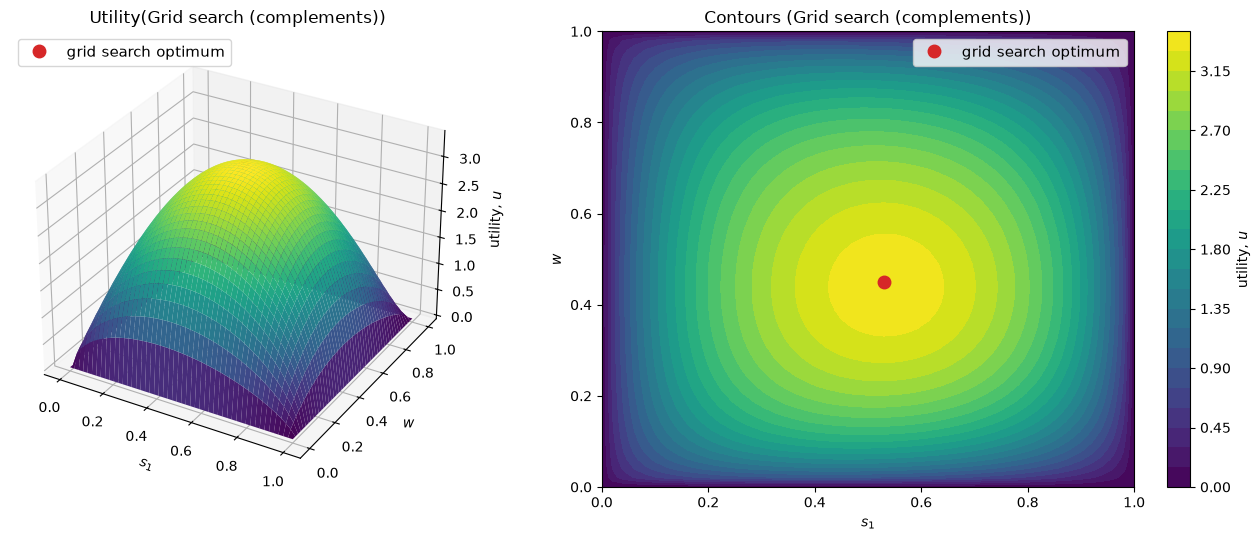

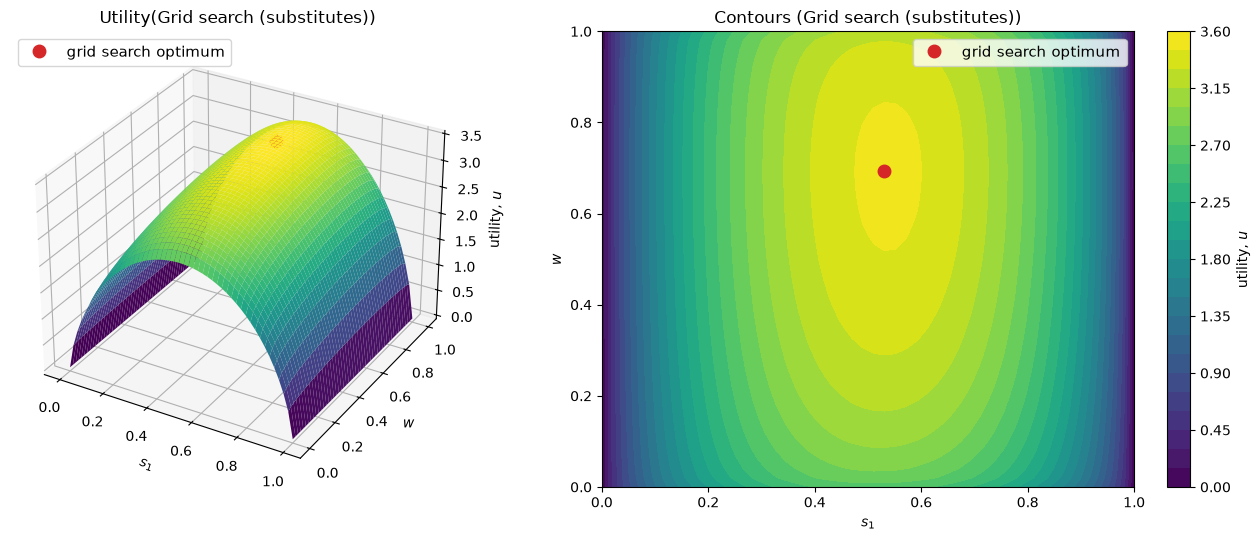

In [ ]:
plot_grid(opt_grid_complements, title="Grid search (complements)")
plot_grid(opt_grid_substitutes, title="Grid search (substitutes)")


###2.1.3
We increace the number of grid point to examine how much this affect our answers. 


In [ ]:
N_values = [50, 100, 200, 500, 1000]
results = []
for N in N_values:
    opt_grid_complements = model_complements.solve_grid(N=N)
    opt_grid_substitutes = model_substitutes.solve_grid(N=N)
    



grid search with (2500 evaluations)
  s1 = 0.530612, w = 0.448980
  shares: 0.530612, 0.210746, 0.258642 (sum = 1.000000)
  u = 3.400748
grid search with (2500 evaluations)
  s1 = 0.530612, w = 0.693878
  shares: 0.530612, 0.325698, 0.143690 (sum = 1.000000)
  u = 3.484594
